# EDA
Notebook khám phá dữ liệu (EDA). Các cell dưới sử dụng `df` được load ở đầu notebook.

In [ ]:
# ---- Setup imports & load dataset ----
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ensure we can import from project root even when notebook is in notebooks/
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src' / 'diabetes_dw_prediction').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

from src.diabetes_dw_prediction.data_loading import load_and_prepare_brfss

df = load_and_prepare_brfss()
display(df.head(3))

In [4]:
print("--- THÔNG TIN CẤU TRÚC DỮ LIỆU ---")
df.info()

--- THÔNG TIN CẤU TRÚC DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth          

In [5]:
# Tính toán thống kê mô tả và chuyển vị bảng
statistical_summary = df.describe().T

display(statistical_summary.round(2))

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.14,0.35,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.43,0.49,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.42,0.49,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.96,0.19,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.38,6.61,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.44,0.50,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.04,0.20,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.09,0.29,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.76,0.43,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.63,0.48,0.0,0.0,1.0,1.0,1.0


In [6]:
print("--- SỐ LƯỢNG GIÁ TRỊ DUY NHẤT CỦA TỪNG CỘT ---")
unique_counts = df.nunique().sort_values()

# In ra các cột và số lượng giá trị duy nhất của nó
for col, count in unique_counts.items():
    print(f"- Cột '{col}': {count} giá trị duy nhất")


--- SỐ LƯỢNG GIÁ TRỊ DUY NHẤT CỦA TỪNG CỘT ---
- Cột 'Diabetes_binary': 2 giá trị duy nhất
- Cột 'Sex': 2 giá trị duy nhất
- Cột 'DiffWalk': 2 giá trị duy nhất
- Cột 'NoDocbcCost': 2 giá trị duy nhất
- Cột 'AnyHealthcare': 2 giá trị duy nhất
- Cột 'HvyAlcoholConsump': 2 giá trị duy nhất
- Cột 'Fruits': 2 giá trị duy nhất
- Cột 'PhysActivity': 2 giá trị duy nhất
- Cột 'Veggies': 2 giá trị duy nhất
- Cột 'Stroke': 2 giá trị duy nhất
- Cột 'Smoker': 2 giá trị duy nhất
- Cột 'CholCheck': 2 giá trị duy nhất
- Cột 'HighChol': 2 giá trị duy nhất
- Cột 'HighBP': 2 giá trị duy nhất
- Cột 'HeartDiseaseorAttack': 2 giá trị duy nhất
- Cột 'GenHlth': 5 giá trị duy nhất
- Cột 'Education': 6 giá trị duy nhất
- Cột 'Income': 8 giá trị duy nhất
- Cột 'Age': 13 giá trị duy nhất
- Cột 'MentHlth': 31 giá trị duy nhất
- Cột 'PhysHlth': 31 giá trị duy nhất
- Cột 'BMI': 84 giá trị duy nhất


In [7]:
# Chọn các biến thứ bậc quan trọng cần xem xét
ordinal_cols = ['GenHlth', 'Education', 'Income']

for col in ordinal_cols:
    print(f"\n--- Phân bố của cột: {col} ---")
    counts = df[col].value_counts().sort_index()
    percentages = df[col].value_counts(normalize=True).sort_index() * 100
    

    summary_df = pd.DataFrame({
        'Số lượng': counts,
        'Tỷ lệ (%)': percentages.round(2)
    })
    display(summary_df)


--- Phân bố của cột: GenHlth ---


,Số lượng,Tỷ lệ (%)
GenHlth,,
1.0,45299,17.86
2.0,89084,35.12
3.0,75646,29.82
4.0,31570,12.44
5.0,12081,4.76



--- Phân bố của cột: Education ---


,Số lượng,Tỷ lệ (%)
Education,,
1.0,174,0.07
2.0,4043,1.59
3.0,9478,3.74
4.0,62750,24.74
5.0,69910,27.56
6.0,107325,42.31



--- Phân bố của cột: Income ---


,Số lượng,Tỷ lệ (%)
Income,,
1.0,9811,3.87
2.0,11783,4.64
3.0,15994,6.30
4.0,20135,7.94
5.0,25883,10.20
6.0,36470,14.38
7.0,43219,17.04
8.0,90385,35.63


In [9]:
null_counts = df.isnull().sum().sum()
print(f"Tổng số giá trị khuyết thiếu (Null): {null_counts}")

print("\n--- SỐ LƯỢNG GIÁ TRỊ PHÂN BIỆT (CARDINALITY) ---")
unique_counts = df.nunique().sort_values()
cardinality_df = pd.DataFrame({'Thuộc tính': unique_counts.index, 'Số giá trị Unique': unique_counts.values})
display(cardinality_df.T)

Tổng số giá trị khuyết thiếu (Null): 0

--- SỐ LƯỢNG GIÁ TRỊ PHÂN BIỆT (CARDINALITY) ---


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
Thuộc tính,Diabetes_binary,Sex,DiffWalk,NoDocbcCost,AnyHealthcare,HvyAlcoholConsump,Fruits,PhysActivity,Veggies,Stroke,...,HighChol,HighBP,HeartDiseaseorAttack,GenHlth,Education,Income,Age,MentHlth,PhysHlth,BMI
Số giá trị Unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,5,6,8,13,31,31,84


### EDA

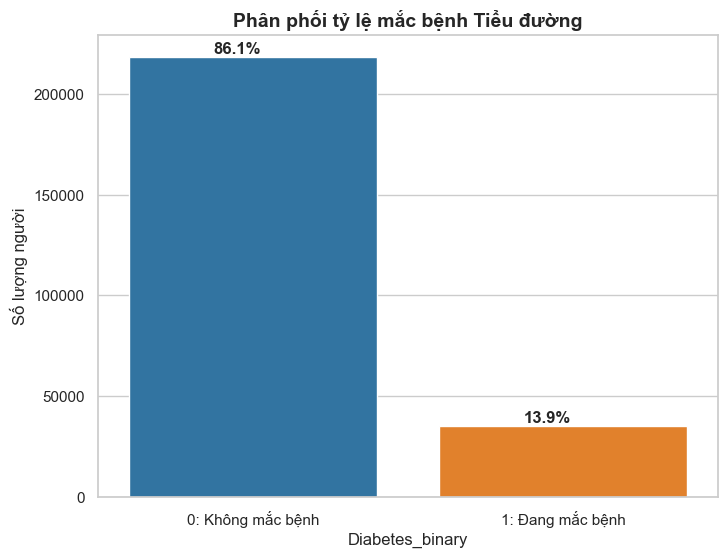

In [10]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Diabetes_binary', data=df, palette=['#1f77b4', '#ff7f0e'])

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Phân phối tỷ lệ mắc bệnh Tiểu đường', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['0: Không mắc bệnh', '1: Đang mắc bệnh'])
plt.ylabel('Số lượng người')
plt.show()

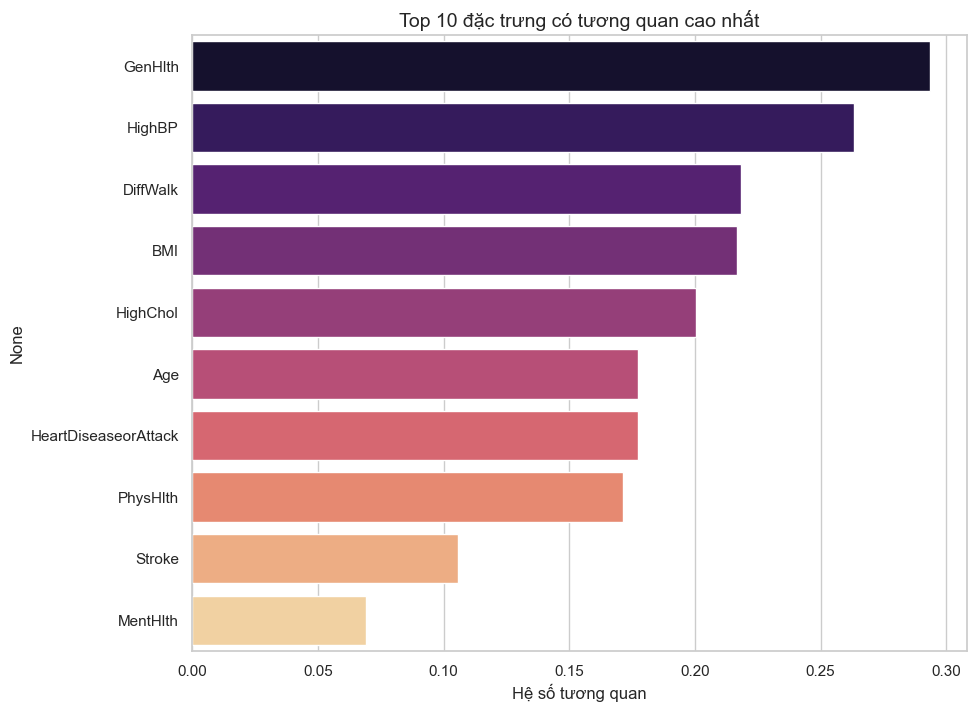

In [11]:
plt.figure(figsize=(10, 8))

corr_matrix = df.corr()
target_corr = corr_matrix['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)

sns.barplot(x=target_corr.head(10).values, y=target_corr.head(10).index, palette='magma')
plt.title('Top 10 đặc trưng có tương quan cao nhất', fontsize=14)
plt.xlabel('Hệ số tương quan')
plt.show()

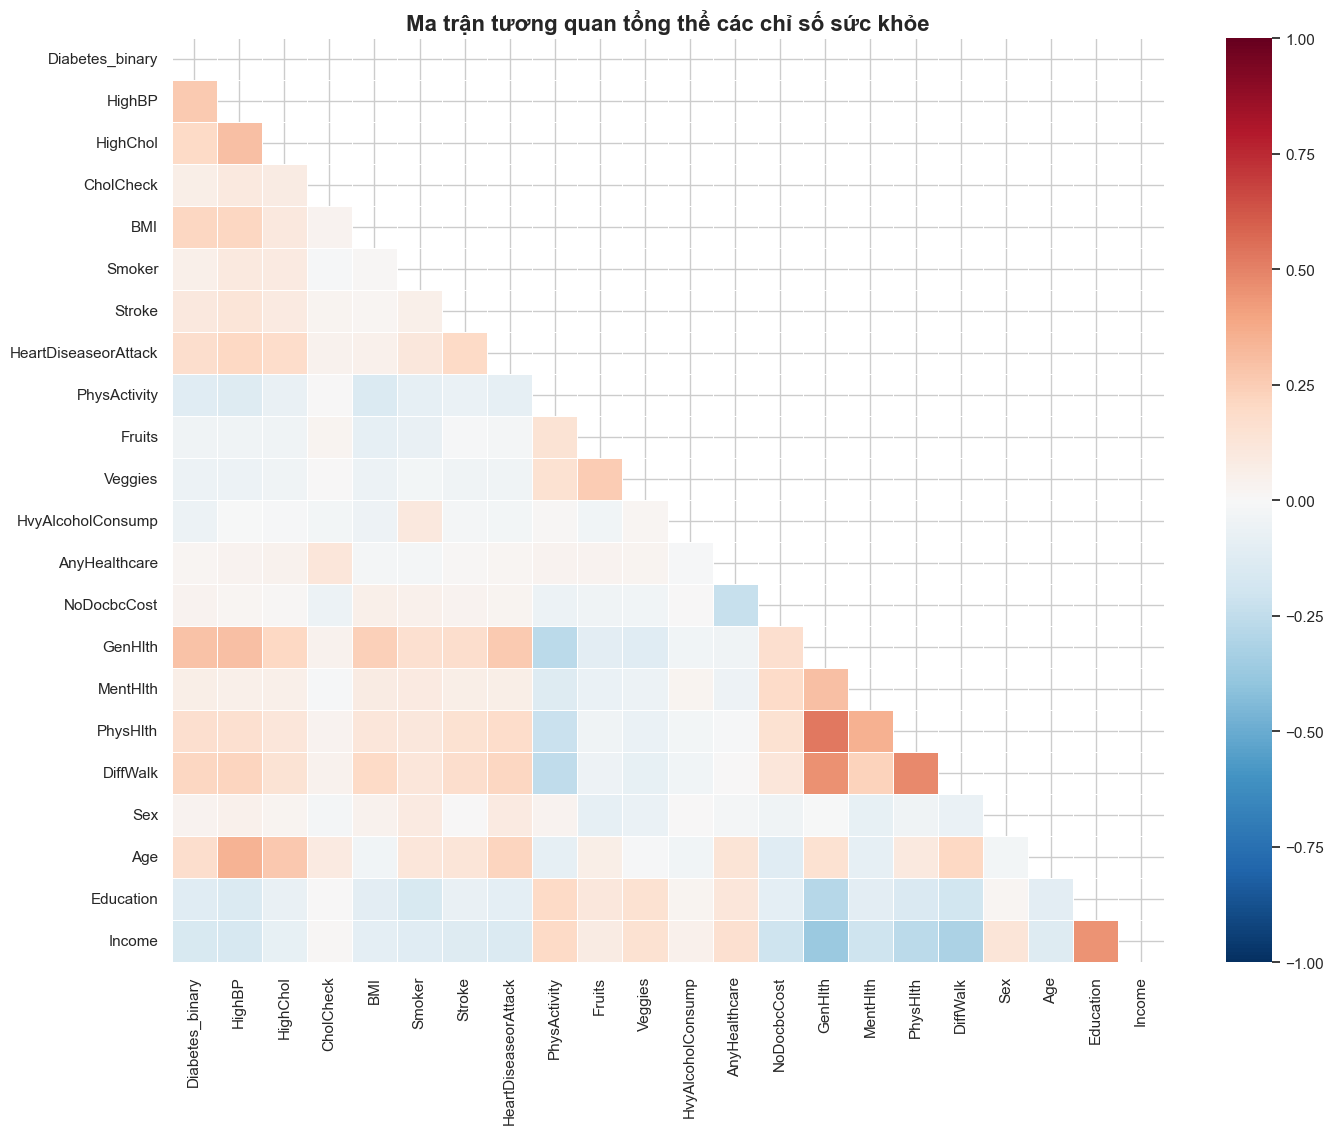

In [12]:
plt.figure(figsize=(16, 12))

# Tính toán ma trận tương quan Pearson
corr = df.corr()

# Tạo mask để che nửa trên của ma trận (vì nó đối xứng)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Vẽ Heatmap
sns.heatmap(corr, mask=mask, cmap='RdBu_r', annot=False, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan tổng thể các chỉ số sức khỏe', fontsize=16, fontweight='bold')
plt.show()

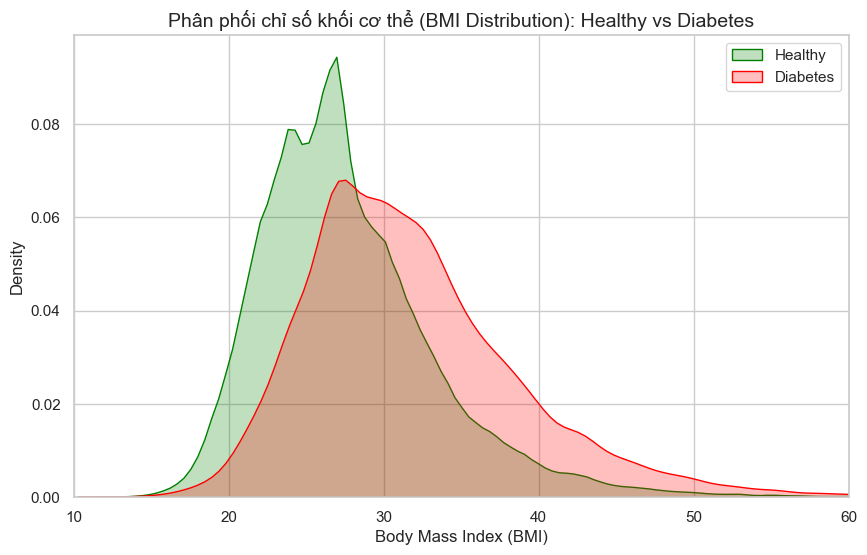

In [13]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df[df['Diabetes_binary']==0], x='BMI', fill=True, color='green', label='Healthy')
sns.kdeplot(data=df[df['Diabetes_binary']==1], x='BMI', fill=True, color='red', label='Diabetes')

plt.title('Phân phối chỉ số khối cơ thể (BMI Distribution): Healthy vs Diabetes', fontsize=14)
plt.xlim(10, 60) # Membatasi sumbu X agar outlier ekstrem tidak merusak tampilan
plt.xlabel('Body Mass Index (BMI)')
plt.legend()

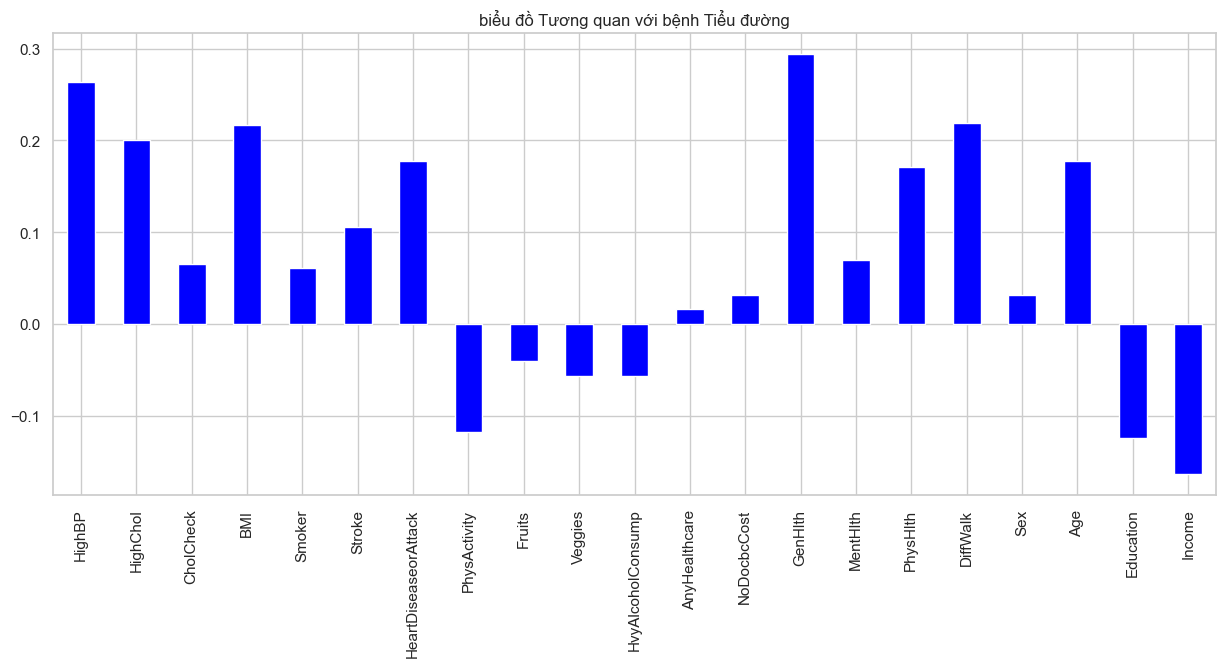

In [14]:
df.drop('Diabetes_binary', axis=1).corrwith(df.Diabetes_binary).plot(kind='bar', grid=True, figsize=(15, 6)
, title="biểu đồ Tương quan với bệnh Tiểu đường",color="blue");

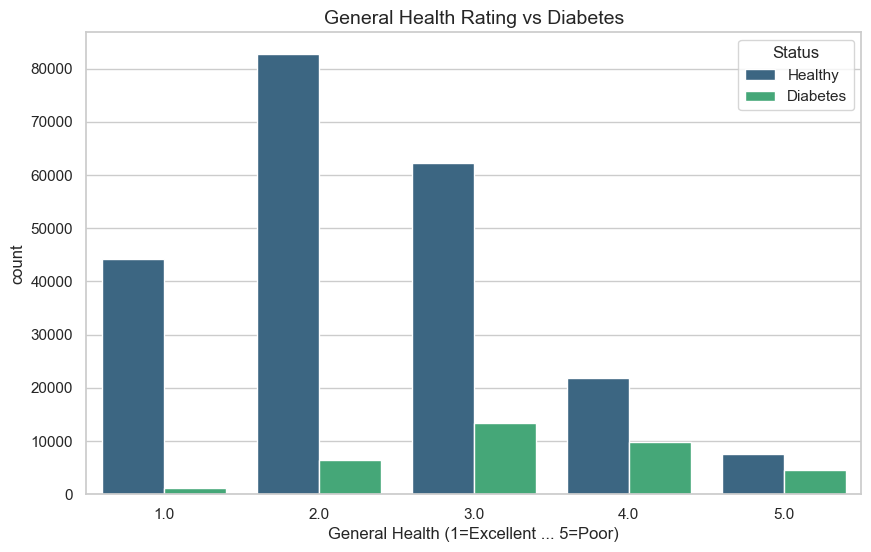

In [15]:
plt.figure(figsize=(10, 6))

sns.countplot(x='GenHlth', hue='Diabetes_binary', data=df, palette='viridis')
plt.title('General Health Rating vs Diabetes', fontsize=14)
plt.xlabel('General Health (1=Excellent ... 5=Poor)')
plt.legend(title='Status', labels=['Healthy', 'Diabetes'])

<Axes: >

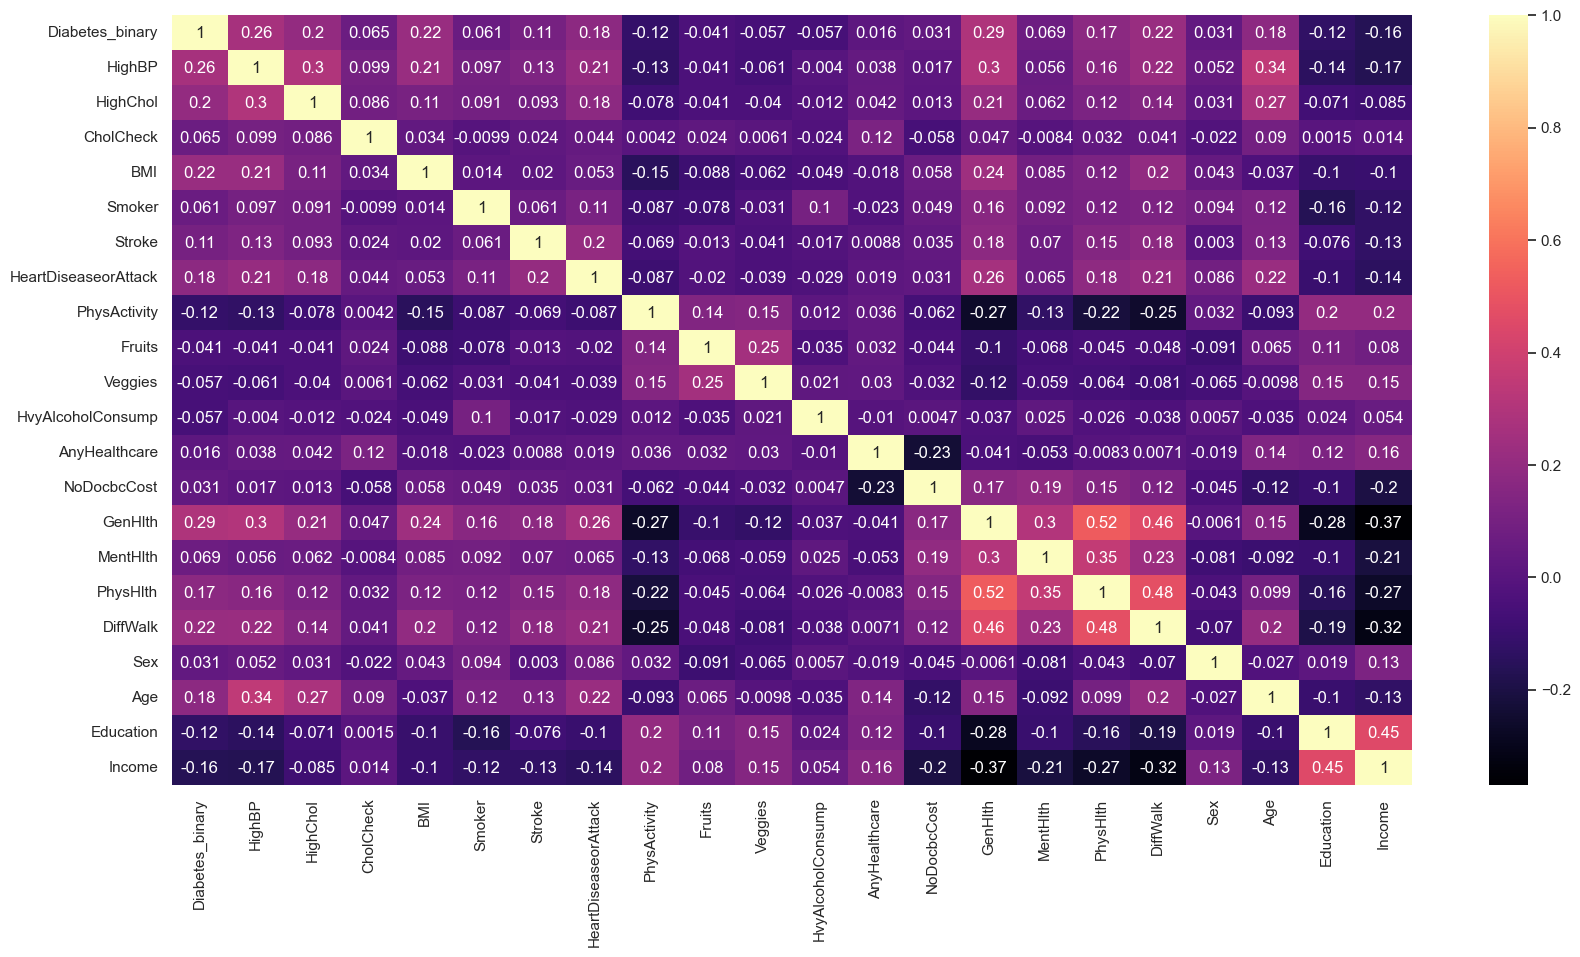

In [16]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap="magma")

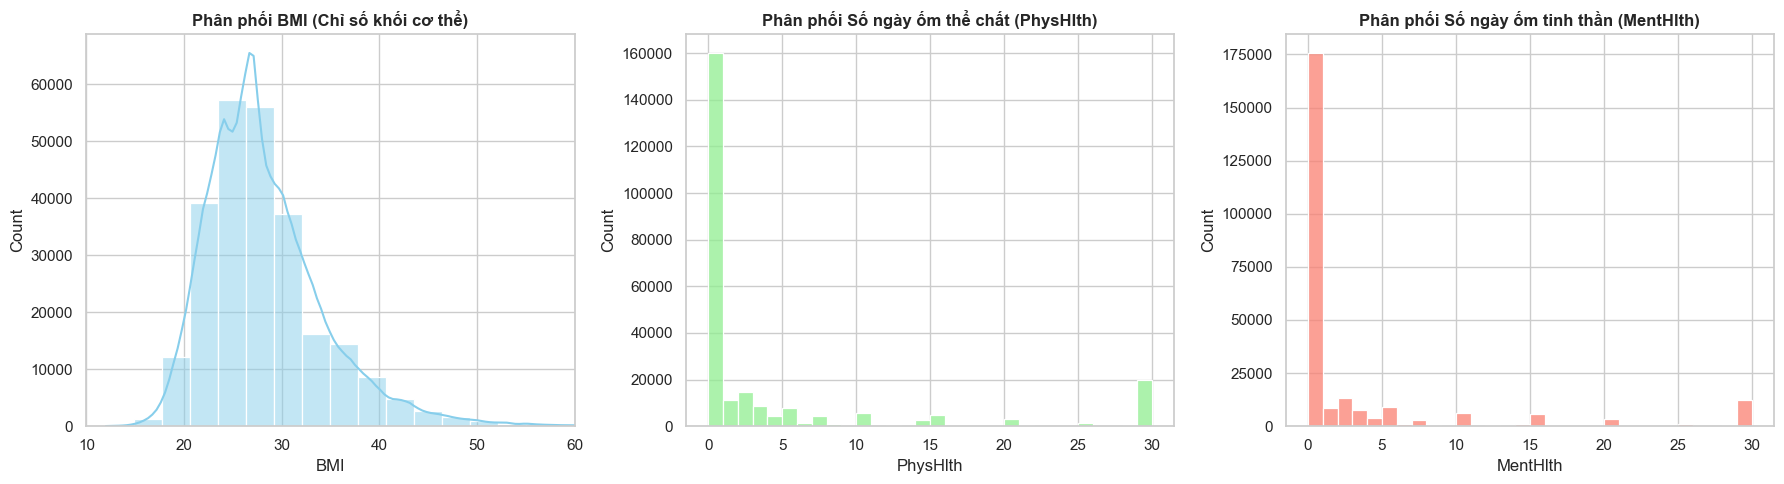

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['BMI'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Phân phối BMI (Chỉ số khối cơ thể)', fontweight='bold')
axes[0].set_xlim(10, 60)

sns.histplot(df['PhysHlth'], bins=30, color='lightgreen', ax=axes[1])
axes[1].set_title('Phân phối Số ngày ốm thể chất (PhysHlth)', fontweight='bold')

sns.histplot(df['MentHlth'], bins=30, color='salmon', ax=axes[2])
axes[2].set_title('Phân phối Số ngày ốm tinh thần (MentHlth)', fontweight='bold')

plt.tight_layout()
plt.show()

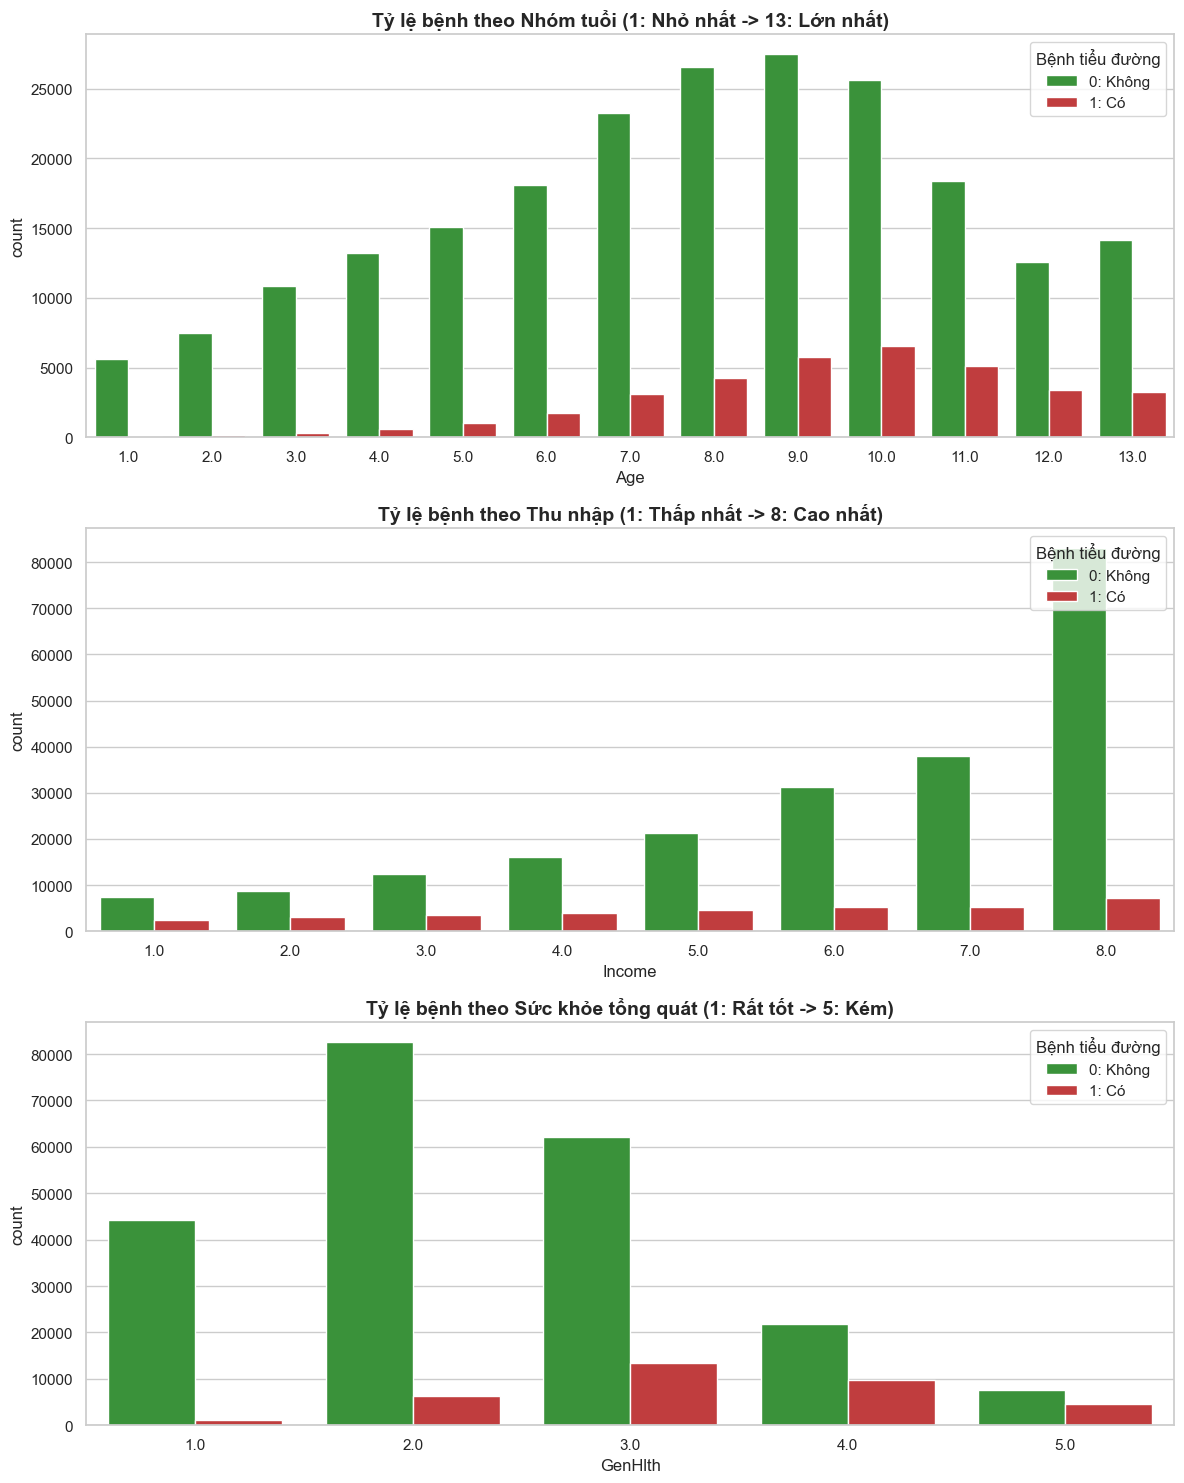

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Hàm phụ để vẽ biểu đồ countplot có nhãn (học từ ML EDA)
def plot_categorical(col, title, ax_idx):
    sns.countplot(data=df, x=col, hue='Diabetes_binary', ax=axes[ax_idx], palette=['#2ca02c', '#d62728'])
    axes[ax_idx].set_title(title, fontweight='bold', fontsize=14)
    axes[ax_idx].legend(title='Bệnh tiểu đường', labels=['0: Không', '1: Có'], loc='upper right')

# Vẽ 3 biểu đồ
plot_categorical('Age', 'Tỷ lệ bệnh theo Nhóm tuổi (1: Nhỏ nhất -> 13: Lớn nhất)', 0)
plot_categorical('Income', 'Tỷ lệ bệnh theo Thu nhập (1: Thấp nhất -> 8: Cao nhất)', 1)
plot_categorical('GenHlth', 'Tỷ lệ bệnh theo Sức khỏe tổng quát (1: Rất tốt -> 5: Kém)', 2)

plt.tight_layout()
plt.show()